In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_NAME = "Qwen/Qwen3-1.7B"
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tok = TOKENIZER
tokenizer = TOKENIZER
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.padding_side = 'left'

embedding = model.get_input_embeddings().weight.data.detach()
print("Embedding shape:", embedding.shape)  # (vocab_size, hidden_dim)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding shape: torch.Size([151936, 2048])


In [3]:
import torch

# 假设 V 是你的词表张量，形状为 (150000, 2048)，已加载到 GPU
V = embedding.cuda()  # 将词表张量移动到 GPU 上

max_distance = 0.0
chunk_size = 5000 # 根据你的 GPU 显存调整

# 分块计算成对距离，寻找最大值
for i in range(0, V.size(0), chunk_size):
    chunk_A = V[i:i+chunk_size]
    for j in range(i, V.size(0), chunk_size): # 对称矩阵，只需算上半部分
        chunk_B = V[j:j+chunk_size]
        # 计算块之间的 L2 距离矩阵
        dists = torch.cdist(chunk_A, chunk_B, p=2.0)
        current_max = dists.max().item()
        if current_max > max_distance:
            max_distance = current_max

print(f"该凸包的直径为: {max_distance}")

该凸包的直径为: 3.191929578781128


In [4]:
import torch

V = embedding.cuda()

# 初始化球心 c 为所有点的均值
c = torch.nn.Parameter(V.mean(dim=0, keepdim=True))
optimizer = torch.optim.Adam([c], lr=0.1)

# 简单迭代优化
for step in range(10000):
    optimizer.zero_grad()
    # 计算当前球心到所有点的距离平方
    distances_sq = torch.sum((V - c)**2, dim=1)
    # 取最大的距离（即当前包住所有点的球的半径平方）
    max_dist_sq = torch.max(distances_sq)
    
    # 最小化这个最大距离
    max_dist_sq.backward()
    optimizer.step()
    
    if step % 200 == 0:
        print(f"Step {step}, 当前外接球半径: {torch.sqrt(max_dist_sq).item():.4f}")

radius = torch.sqrt(torch.max(torch.sum((V - c)**2, dim=1))).item()
print(f"最终凸包的外接球半径约为: {radius}")

Step 0, 当前外接球半径: 2.2296
Step 200, 当前外接球半径: 2.6299
Step 400, 当前外接球半径: 2.5551
Step 600, 当前外接球半径: 2.5581
Step 800, 当前外接球半径: 2.5596
Step 1000, 当前外接球半径: 2.5604
Step 1200, 当前外接球半径: 2.5609
Step 1400, 当前外接球半径: 2.5612
Step 1600, 当前外接球半径: 2.5614
Step 1800, 当前外接球半径: 2.5616
Step 2000, 当前外接球半径: 2.5617
Step 2200, 当前外接球半径: 2.5618
Step 2400, 当前外接球半径: 2.5618
Step 2600, 当前外接球半径: 2.5619
Step 2800, 当前外接球半径: 2.5619
Step 3000, 当前外接球半径: 2.5619
Step 3200, 当前外接球半径: 2.5619
Step 3400, 当前外接球半径: 2.5619
Step 3600, 当前外接球半径: 2.5620
Step 3800, 当前外接球半径: 2.5620
Step 4000, 当前外接球半径: 2.5620
Step 4200, 当前外接球半径: 2.5620
Step 4400, 当前外接球半径: 2.5620
Step 4600, 当前外接球半径: 2.5620


KeyboardInterrupt: 

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

# ==========================================
# 1. 核心几何参数设定 (基于 Qwen3-1.7B 词表推导)
# ==========================================
R = 2.56                   # 外接球半径
theta_max_deg = 77         # 向量簇的最大总张角
theta_half_rad = np.radians(theta_max_deg / 2)
num_points_3d = 800        # 采样点数量

# ==========================================
# 2. 生成三维空间下的点集与凸包
# ==========================================
# 在 3D 圆锥内采样 (使用球面坐标)
phi = np.random.uniform(0, 2 * np.pi, num_points_3d) 
costheta = np.random.uniform(np.cos(theta_half_rad), 1, num_points_3d)
theta = np.arccos(costheta)
r_3d = np.random.normal(R, 0.05, num_points_3d)

# 转换为笛卡尔坐标 (让花束朝向上方 Z 轴)
x_3d = r_3d * np.sin(theta) * np.cos(phi)
y_3d = r_3d * np.sin(theta) * np.sin(phi)
z_3d = r_3d * np.cos(theta)
points_3d = np.column_stack((x_3d, y_3d, z_3d))

# 计算 3D 凸包
hull_3d = ConvexHull(points_3d)

# 提取凸包的三角形面 (Simplices) 用于 Plotly 的 Mesh3d 渲染
i = hull_3d.simplices[:, 0]
j = hull_3d.simplices[:, 1]
k = hull_3d.simplices[:, 2]

# ==========================================
# 3. 构建 Plotly 交互式图表
# ==========================================
fig = go.Figure()

# --- 添加凸包表面 (Mesh) ---
fig.add_trace(go.Mesh3d(
    x=x_3d, y=y_3d, z=z_3d,
    i=i, j=j, k=k,
    color='coral',        # 凸包颜色
    opacity=0.3,          # 透明度，方便看清内部
    flatshading=True,     # 开启平面着色，凸显多面体的棱角感
    name='Convex Hull Boundary'
))

# --- 添加词向量采样点 (Scatter3d) ---
fig.add_trace(go.Scatter3d(
    x=x_3d, y=y_3d, z=z_3d,
    mode='markers',
    marker=dict(size=2.5, color='dodgerblue', opacity=0.8),
    name='Word Vectors'
))

# --- 添加原点 (Origin) ---
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers+text',
    marker=dict(size=6, color='black'),
    text=['Origin (0,0,0)'],
    textposition="bottom center",
    name='Origin'
))

# --- 添加一根连接原点和某一点的参考线，凸显“高度/半径” ---
fig.add_trace(go.Scatter3d(
    x=[0, x_3d[0]], y=[0, y_3d[0]], z=[0, z_3d[0]],
    mode='lines',
    line=dict(color='gray', width=2, dash='dash'),
    name='Vector Path (R ≈ 2.56)'
))

# ==========================================
# 4. 设置布局，确保比例为 1:1:1
# ==========================================
# 这一步极其重要，否则 Plotly 会自动拉伸坐标轴，破坏真实的几何直觉
max_range = R * 1.1
fig.update_layout(
    title="Interactive 3D View: The 'Spherical Cap' Convex Hull of Word Embeddings",
    scene=dict(
        xaxis=dict(range=[-max_range, max_range], title='X'),
        yaxis=dict(range=[-max_range, max_range], title='Y'),
        zaxis=dict(range=[0, max_range*1.2], title='Z'),
        aspectmode='cube' # 强制 x, y, z 轴的物理视觉比例绝对一致
    ),
    width=900,
    height=800,
    margin=dict(l=0, r=0, b=0, t=50) # 减少边缘留白
)

fig.show()

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go

def plot_qwen_embeddings_3d_tsne(embedding_matrix, n_samples=1000, perplexity=30, random_state=42):
    """
    随机采样高维 Embedding 并使用 t-SNE 降维到 3D 进行交互式可视化。
    
    参数:
    embedding_matrix: numpy array, 形状应为 (vocab_size, hidden_dim)，例如 (150000, 2048)
    n_samples: int, 采样的点数，默认 1000
    perplexity: int, t-SNE 的困惑度参数，通常在 5 到 50 之间
    """
    vocab_size, hidden_dim = embedding_matrix.shape
    print(f"原始词表维度: {vocab_size} 个 {hidden_dim} 维向量")
    
    # 1. 随机采样 1000 个点
    # 为了保证每次运行结果一致，设置了 random_state
    np.random.seed(random_state)
    sampled_indices = np.random.choice(vocab_size, n_samples, replace=False)
    sampled_vectors = embedding_matrix[sampled_indices]
    
    print(f"已采样 {n_samples} 个点，正在进行 t-SNE 降维 (这可能需要十几秒)...")
    
    # 2. t-SNE 降维到 3D
    tsne = TSNE(n_components=3, perplexity=perplexity, random_state=random_state, init='pca', learning_rate='auto')
    vectors_3d = tsne.fit_transform(sampled_vectors)
    
    print("降维完成，正在生成 3D 交互视图...")
    
    # 3. 使用 Plotly 绘制交互式 3D 散点图
    fig = go.Figure(data=[go.Scatter3d(
        x=vectors_3d[:, 0],
        y=vectors_3d[:, 1],
        z=vectors_3d[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            # 使用 z 轴的值作为颜色映射，增加层次感
            color=vectors_3d[:, 2], 
            colorscale='Viridis',   
            opacity=0.8
        ),
        # 悬停时显示该点在原始词表中的索引
        text=[f"Vocab Index: {idx}" for idx in sampled_indices], 
        hoverinfo='text'
    )])
    
    # 优化布局视觉效果
    fig.update_layout(
        title=f"t-SNE 3D Projection of {n_samples} Random Qwen Embeddings",
        scene=dict(
            xaxis_title='t-SNE 1',
            yaxis_title='t-SNE 2',
            zaxis_title='t-SNE 3',
            bgcolor='rgb(240, 240, 240)' # 设置一个浅灰背景让亮点更突出
        ),
        width=900,
        height=800,
        margin=dict(l=0, r=0, b=0, t=40)
    )
    
    fig.show()

# ==========================================
# 使用示例：
# ==========================================
# 假设你已经从模型中提取了真实的权重并转为了 numpy array
# 例如：real_qwen_embeddings = model.model.embed_tokens.weight.detach().cpu().numpy()

# 这里我们生成一个假的 dummy_matrix 来模拟 (150000, 2048) 的规模供你直接测试代码
print("初始化模拟数据...")
dummy_matrix = np.random.randn(150000, 2048) 
# 为了模拟词向量的特性，通常会对隐状态做一个 L2 归一化或层归一化
dummy_matrix = dummy_matrix / np.linalg.norm(dummy_matrix, axis=1, keepdims=True)
dummy_matrix = embedding.cpu().numpy()  # 替换为真实的词向量矩阵
# 调用函数
plot_qwen_embeddings_3d_tsne(dummy_matrix, n_samples=1000, perplexity=30)

初始化模拟数据...
原始词表维度: 151936 个 2048 维向量
已采样 1000 个点，正在进行 t-SNE 降维 (这可能需要十几秒)...
降维完成，正在生成 3D 交互视图...


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go

def plot_qwen_embeddings_3d_pca(embedding_matrix, n_samples=2000, random_state=42):
    """
    随机采样高维 Embedding 并使用 PCA 线性降维到 3D 进行交互式可视化。
    PCA 能最大程度保留全局几何结构，适合观察词表的真实形状。
    """
    vocab_size, hidden_dim = embedding_matrix.shape
    print(f"原始词表维度: {vocab_size} 个 {hidden_dim} 维向量")
    
    # 1. 随机采样（建议增加采样点到 2000，以更好地勾勒轮廓）
    np.random.seed(random_state)
    n_samples = min(n_samples, vocab_size)
    sampled_indices = np.random.choice(vocab_size, n_samples, replace=False)
    sampled_vectors = embedding_matrix[sampled_indices]
    
    print(f"已采样 {n_samples} 个点，正在进行 PCA 降维...")
    
    # 2. PCA 降维到 3D
    # 注意：为了观察原点，我们不应该让 PCA 自动减去均值（去中心化）。
    # scikit-learn 的 PCA 默认会去中心化。为了保留原点 (0,0,0) 的相对位置，
    # 我们使用其底层的 TruncatedSVD，或者在投影前手动加上均值。
    
    # 这里我们使用一个更直观的方法：在数据中手动加入原点 (0,0,0)，
    # 然后一起进行 PCA。
    origin = np.zeros((1, hidden_dim))
    vectors_with_origin = np.vstack([sampled_vectors, origin])
    
    pca = PCA(n_components=3)
    # 计算主成分 (基于包含原点的数据，确保投影保留方向性)
    vectors_with_origin_3d = pca.fit_transform(vectors_with_origin)
    
    # 提取降维后的词向量和原点坐标
    vectors_3d = vectors_with_origin_3d[:-1, :]
    origin_3d = vectors_with_origin_3d[-1, :]
    
    # 计算方差解释率，了解 3D 保留了多少信息
    explained_variance = pca.explained_variance_ratio_
    print(f"PCA 前三个主成分解释的方差比例: {sum(explained_variance)*100:.1f}%")
    
    print("降维完成，正在生成 3D 交互视图...")
    
    # 3. 使用 Plotly 绘制交互式 3D 散点图
    fig = go.Figure()

    # --- 添加词向量采样点 ---
    fig.add_trace(go.Scatter3d(
        x=vectors_3d[:, 0],
        y=vectors_3d[:, 1],
        z=vectors_3d[:, 2],
        mode='markers',
        marker=dict(
            size=3,
            # 使用 z 轴的值作为颜色映射，增加立体感
            color=vectors_3d[:, 2], 
            colorscale='YlGnBu', # 选择一个优雅的颜色盘
            opacity=0.6
        ),
        text=[f"Vocab Index: {idx}" for idx in sampled_indices], 
        hoverinfo='text',
        name='Word Embeddings'
    ))

    # --- 添加原点 (0,0,0) 的投影位置 ---
    # 我们用一个醒目的黑色大点标出
    fig.add_trace(go.Scatter3d(
        x=[origin_3d[0]],
        y=[origin_3d[1]],
        z=[origin_3d[2]],
        mode='markers+text',
        marker=dict(size=10, color='black'),
        text=['Origin (0,0,0)'],
        textposition="bottom center",
        name='Projected Origin'
    ))

    # --- 添加一根连接原点和中心向量的参考线，凸显“高度/偏斜” ---
    center_vec_3d = vectors_3d.mean(axis=0)
    fig.add_trace(go.Scatter3d(
        x=[origin_3d[0], center_vec_3d[0]], 
        y=[origin_3d[1], center_vec_3d[1]], 
        z=[origin_3d[2], center_vec_3d[2]],
        mode='lines',
        line=dict(color='gray', width=2, dash='dash'),
        name='Vector Path'
    ))

    # 4. 优化布局，确保比例为 1:1:1，保留真实几何感
    # 这一步极其重要，防止坐标轴自动拉伸
    all_points = vectors_with_origin_3d
    max_range = np.max(np.abs(all_points)) * 1.1
    
    fig.update_layout(
        title=f"PCA 3D Linear Projection of {n_samples} Random Qwen Embeddings (Origin Preserved)",
        scene=dict(
            xaxis=dict(range=[-max_range, max_range], title='PCA 1'),
            yaxis=dict(range=[-max_range, max_range], title='PCA 2'),
            zaxis=dict(range=[-max_range, max_range], title='PCA 3'),
            aspectmode='cube' # 强制 x, y, z 轴视觉比例一致
        ),
        width=900,
        height=800,
        margin=dict(l=0, r=0, b=0, t=40)
    )
    
    fig.show()

# ==========================================
# 使用示例：
# ==========================================
# 这里我们生成一个假的 dummy_matrix 来模拟 (150000, 2048) 的规模供你直接测试代码
print("初始化模拟数据...")
# dummy_matrix = np.random.randn(150000, 2048) 

# 为了模拟真实的 LLM 词向量特性，我们必须模拟“各向异性”
# # 我们让所有向量在一个狭窄的方向上加上一个巨大的偏移量
# bias_direction = np.zeros(2048)
# bias_direction[0] = 5.0 # 让第一维成为主导
# dummy_matrix = dummy_matrix + bias_direction

# # 对隐状态做一个 L2 归一化，模拟层归一化后的超球面分布
# dummy_matrix = dummy_matrix / np.linalg.norm(dummy_matrix, axis=1, keepdims=True)
dummy_matrix = embedding.cpu().numpy()  # 替换为真实的词向量矩阵


# 调用函数 (建议采样 2000 个点以看清扁平形状)
plot_qwen_embeddings_3d_pca(dummy_matrix, n_samples=10000)

初始化模拟数据...
原始词表维度: 151936 个 2048 维向量
已采样 10000 个点，正在进行 PCA 降维...


PCA 前三个主成分解释的方差比例: 1.5%
降维完成，正在生成 3D 交互视图...


正在初始化数据 (实际使用时请替换为真实张量)...
正在沿 hidden_dim 维度计算所有词向量的 L2 模长...
------------------------------
模长统计信息:
均值 (Mean): 1.5394
标准差 (Std): 0.2601
最小值 (Min): 0.3475
最大值 (Max): 2.3117
------------------------------


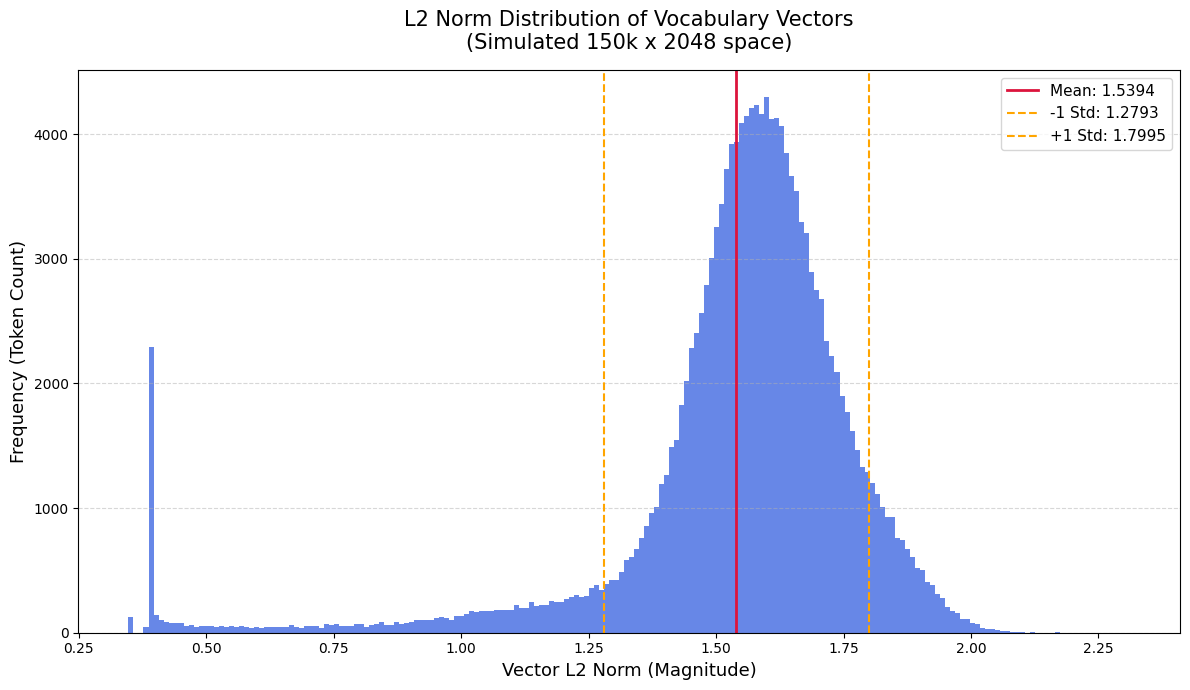

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 模拟 Qwen 词表向量数据 (150000, 2048)
# 注意: 实际实验中请替换为你提取的真实权重，例如:
embedding_matrix = embedding.cpu().numpy()
vocab_size = 150000
hidden_dim = 2048

print("正在初始化数据 (实际使用时请替换为真实张量)...")
# 模拟深度学习中常见的权重初始化分布 (例如 scale=0.02 的截断正态分布)
# embedding_matrix = np.random.normal(loc=0.0, scale=0.02, size=(vocab_size, hidden_dim))

# 2. 计算每个向量的 L2 模长 (Norm)
print("正在沿 hidden_dim 维度计算所有词向量的 L2 模长...")
norms = np.linalg.norm(embedding_matrix, axis=1)

# 计算基础统计信息
mean_norm = np.mean(norms)
std_norm = np.std(norms)
min_norm = np.min(norms)
max_norm = np.max(norms)

print("-" * 30)
print(f"模长统计信息:")
print(f"均值 (Mean): {mean_norm:.4f}")
print(f"标准差 (Std): {std_norm:.4f}")
print(f"最小值 (Min): {min_norm:.4f}")
print(f"最大值 (Max): {max_norm:.4f}")
print("-" * 30)

# 3. 绘制模长分布直方图
plt.figure(figsize=(12, 7))

# 绘制直方图，bins 设为 200 以显示更细致的分布形态
n, bins, patches = plt.hist(norms, bins=200, color='royalblue', edgecolor='none', alpha=0.8)

# 标出均值线和 ±1 倍标准差区间
plt.axvline(mean_norm, color='crimson', linestyle='-', linewidth=2, label=f'Mean: {mean_norm:.4f}')
plt.axvline(mean_norm - std_norm, color='orange', linestyle='--', linewidth=1.5, label=f'-1 Std: {(mean_norm - std_norm):.4f}')
plt.axvline(mean_norm + std_norm, color='orange', linestyle='--', linewidth=1.5, label=f'+1 Std: {(mean_norm + std_norm):.4f}')

# 优化视觉格式
plt.title('L2 Norm Distribution of Vocabulary Vectors\n(Simulated 150k x 2048 space)', fontsize=15, pad=15)
plt.xlabel('Vector L2 Norm (Magnitude)', fontsize=13)
plt.ylabel('Frequency (Token Count)', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# 自动调整布局并显示
plt.tight_layout()
plt.show()

